# APS 1 - Compreendendo os desertos de notícias do Brasil

### Brenda Lima & Miqueias Ayron

## Setup

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Carregando e Visualizando os Dados

In [27]:
df = pd.read_csv('data/csv-3.csv')
df.head()

,Unnamed: 0,Cód Mun. (IBGE),Município,UF,Região,População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
0,1,1100031,Cabixi,RO,Norte,5363,2022,0.650,0.650,0.559
1,2,1100072,Corumbiara,RO,Norte,7519,2022,0.613,0.630,0.473
2,3,1100148,Nova Brasilândia D'Oeste,RO,Norte,15679,2022,0.643,0.664,0.524
3,4,1100262,Rio Crespo,RO,Norte,3471,2022,0.643,0.637,0.513
4,5,1100379,Alto Alegre dos Parecis,RO,Norte,11479,2022,0.592,0.603,0.443


## Descrição Geral 

In [9]:
df.describe()

,Unnamed: 0,Cód Mun. (IBGE),População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
count,2707.000000,2.707000e+03,2707.000000,2707.0,2704.000000,2704.000000,2704.000000
mean,1354.000000,3.126497e+06,8686.320281,2022.0,0.639421,0.618748,0.537298
std,781.587914,9.067145e+05,7845.450261,0.0,0.068926,0.076516,0.090289
min,1.000000,1.100031e+06,833.000000,2022.0,0.418000,0.400000,0.207000
25%,677.500000,2.413330e+06,3743.000000,2022.0,0.584000,0.555000,0.471000
50%,1354.000000,3.120870e+06,6133.000000,2022.0,0.636000,0.615000,0.533000
75%,2030.500000,3.551158e+06,10881.500000,2022.0,0.699000,0.682000,0.604000
max,2707.000000,5.222302e+06,91767.000000,2022.0,0.806000,0.848000,0.778000


## Descrição da População

In [10]:
df['População'].describe().round().to_frame()

,População
count,2707.0
mean,8686.0
std,7845.0
min,833.0
25%,3743.0
50%,6133.0
75%,10882.0
max,91767.0


## 1. Tabela de Estatísticas Descritivas da População

In [11]:
df_medidas = pd.DataFrame([
    {
        'Média':df['População'].mean(),
        'Mediana':df['População'].median(),
        'Moda':[df['População'].mode()[i] for i in range(len(df['População'].mode()))],
        'Desvio Padrão':df['População'].std(),
        'Variância':(df['População'].std())**2,
        'Mínimo':df['População'].min(),
        'Máximo':df['População'].max(),
        'Total':df['População'].count()
     }
])
df_medidas.round().head()

,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Máximo,Total
0,8686.0,6133.0,"[3747, 4127]",7845.0,61551090.0,833,91767,2707


## 2. Agrupamento de Dados por UF

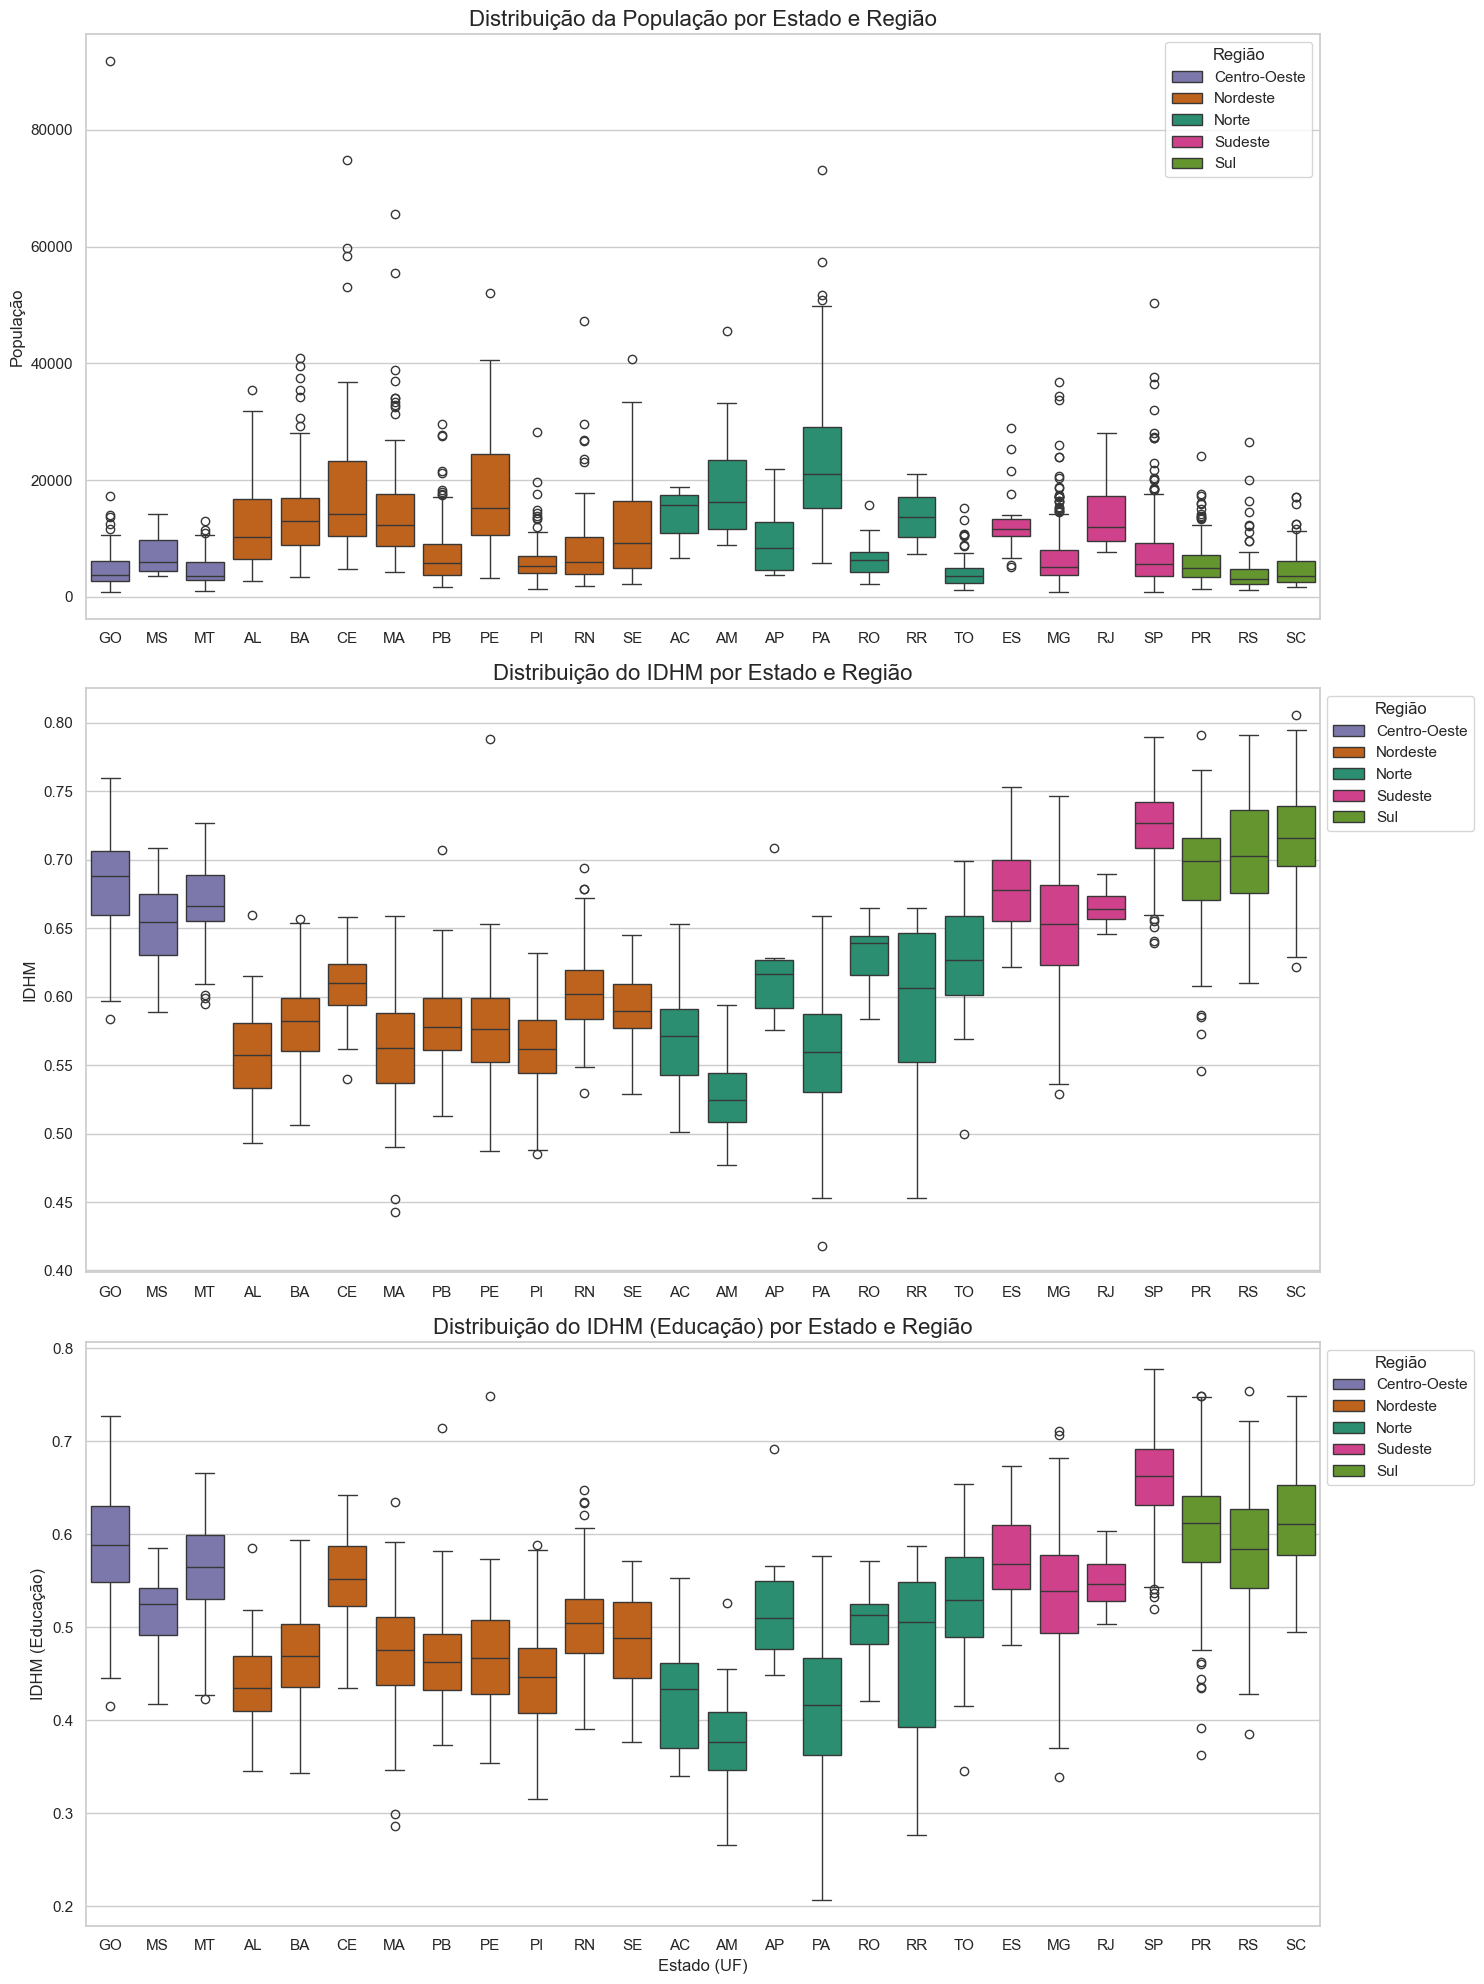

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# meapeamento de regiões
regioes_map = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# cria coluna de região
df['Região'] = df['UF'].map(regioes_map)
df = df.sort_values(['Região', 'UF']) #ordena para agrupar estados da mesma região

sns.set_theme(style="whitegrid")

#plotando os gráficos
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

#paleta de cores por região
paleta_regiao = {
    'Norte': '#1b9e77', 'Nordeste': '#d95f02', 'Centro-Oeste': '#7570b3',
    'Sudeste': '#e7298a', 'Sul': '#66a61e'
}

# População
sns.boxplot(x='UF', y='População', data=df, ax=axes[0], hue='Região', palette=paleta_regiao, dodge=False)
axes[0].set_title('Distribuição da População por Estado e Região', fontsize=16)
axes[0].set_xlabel('')
axes[0].legend(title='Região', bbox_to_anchor=(1, 1))

# IDHM 
sns.boxplot(x='UF', y='IDHM', data=df, ax=axes[1], hue='Região', palette=paleta_regiao, dodge=False)
axes[1].set_title('Distribuição do IDHM por Estado e Região', fontsize=16)
axes[1].set_xlabel('')
axes[1].legend(title='Região', bbox_to_anchor=(1, 1))

# IDHM(Educação
sns.boxplot(x='UF', y='IDHM (Educação)', data=df, ax=axes[2], hue='Região', palette=paleta_regiao, dodge=False)
axes[2].set_title('Distribuição do IDHM (Educação) por Estado e Região', fontsize=16)
axes[2].set_xlabel('Estado (UF)', fontsize=12)
axes[2].legend(title='Região', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

A utilização de **boxplots** para as variáveis de **População**, **IDHM** e **IDHM (Educação)** permitiu uma análise comparativa robusta da distribuição dos dados entre as Unidades da Federação. Esta visualização facilita a identificação de medidas de tendência central, a dispersão interquartílica e a detecção de outliers, evidenciando as disparidades socioeconômicas intraestaduais.

## 3. Municípios no Primeiro Quartil em relação ao IDHM

### DataFrame de municípios agrupados por UF

In [13]:
q1_por_estado = df.groupby('UF')['IDHM'].transform(lambda x: x.quantile(0.25))
df_quartil_estadual = df[df['IDHM'] < q1_por_estado].copy()
df_quartil_estadual.head()

,Unnamed: 0,Cód Mun. (IBGE),Município,UF,Região,População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
2612,2613,5200829,Amaralina,GO,Centro-Oeste,3268,2022,0.609,0.569,0.489
2620,2621,5203104,Baliza,GO,Centro-Oeste,3351,2022,0.655,0.614,0.558
2627,2628,5204656,Campinaçu,GO,Centro-Oeste,3708,2022,0.631,0.644,0.476
2630,2631,5204953,Campos Verdes,GO,Centro-Oeste,4005,2022,0.654,0.608,0.577
2632,2633,5205307,Cavalcante,GO,Centro-Oeste,9589,2022,0.584,0.595,0.415


### Contagem por UF

In [14]:
contagem_uf = df_quartil_estadual['UF'].value_counts().reset_index()
contagem_uf.columns = ['UF', 'Contagem']
contagem_uf

,UF,Contagem
0,MG,123
1,SP,80
2,RS,48
3,BA,44
4,PR,43
5,PI,41
6,PB,36
7,RN,33
8,MA,32
9,SC,31


A análise foi refinada para identificar os municípios situados **abaixo do primeiro quartil (Q1)** de **IDHM em nível estadual**. Esta abordagem permite isolar as disparidades intraestaduais, revelando as áreas que demandam maior atenção prioritária dentro de suas próprias unidades federativas, independentemente do contexto nacional.

## 4. Análise por Região - Nordeste

In [15]:
df_nordeste = df[df['UF'].map(regioes_map) == 'Nordeste'].copy()
df_nordeste.head()

,Unnamed: 0,Cód Mun. (IBGE),Município,UF,Região,População,Ano (população IBGE),IDHM,IDHM (Renda),IDHM (Educação)
935,936,2700102,Água Branca,AL,Nordeste,19008,2022,0.549,0.527,0.432
936,937,2700508,Barra de Santo Antônio,AL,Nordeste,16365,2022,0.557,0.552,0.428
937,938,2700607,Barra de São Miguel,AL,Nordeste,7944,2022,0.615,0.638,0.475
938,939,2700706,Batalha,AL,Nordeste,16448,2022,0.594,0.563,0.496
939,940,2700805,Belém,AL,Nordeste,4722,2022,0.593,0.587,0.464


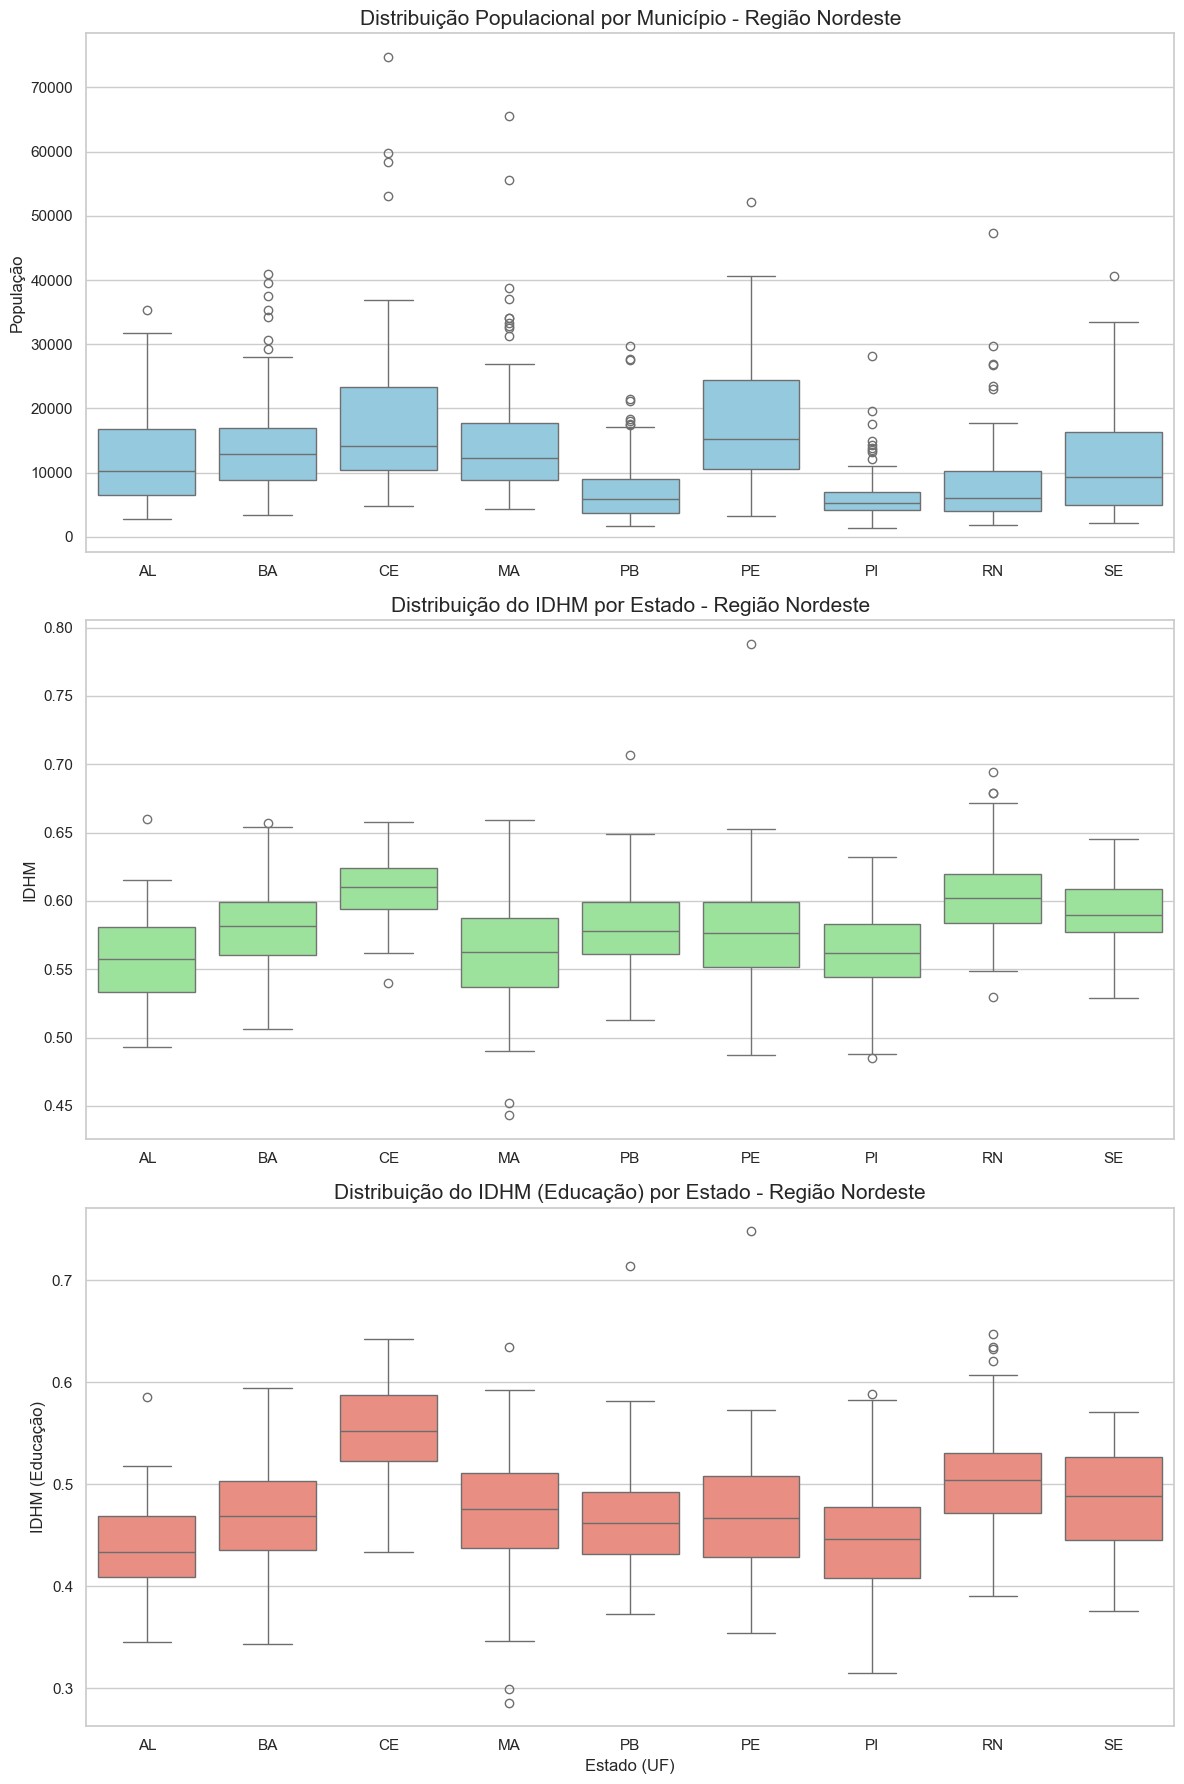

In [16]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

cor_nordeste = '#d95f02' 

sns.boxplot(x='UF', y='População', data=df_nordeste, ax=axes[0], color='#87CEEB')
axes[0].set_title('Distribuição Populacional por Município - Região Nordeste', fontsize=15)
axes[0].set_xlabel('')

sns.boxplot(x='UF', y='IDHM', data=df_nordeste, ax=axes[1], color='#90EE90')
axes[1].set_title('Distribuição do IDHM por Estado - Região Nordeste', fontsize=15)
axes[1].set_xlabel('')

sns.boxplot(x='UF', y='IDHM (Educação)', data=df_nordeste, ax=axes[2], color='#FA8072')
axes[2].set_title('Distribuição do IDHM (Educação) por Estado - Região Nordeste', fontsize=15)
axes[2].set_xlabel('Estado (UF)', fontsize=12)

plt.tight_layout()
plt.show()

### Municípios com IDHM abaixo do primeiro quartil

In [17]:
q1_por_estado_ne = df_nordeste.groupby('UF')['IDHM'].transform(lambda x: x.quantile(0.25))
df_q1_nordeste = df_nordeste[df_nordeste['IDHM'] < q1_por_estado_ne].copy()
df_q1_nordeste['IDHM'].min()

np.float64(0.443)

Os gráficos indicam que a população dos municípios do Nordeste é bastante desigual, com muitos municípios pequenos e poucos muito populosos, gerando assimetria e diversos outliers. Em contraste, o IDHM e o IDHM (Educação) apresentam distribuições mais equilibradas, com menor dispersão e menos valores extremos. Ainda assim, os boxplots mostram diferenças relevantes entre os estados, com medianas e amplitudes distintas, evidenciando que o Nordeste não é homogêneo internamente. A análise dos quartis reforça a existência de desigualdades intraestaduais, indicando a presença de grupos de municípios mais vulneráveis.

## 5. Cálculo de correlação - População e IDH

### Nordeste

Correlação: 0.07506583023997636


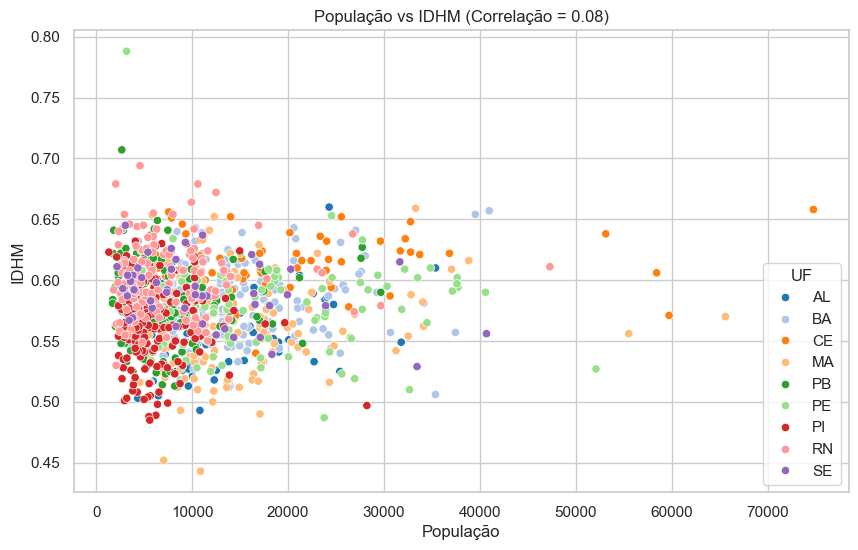

In [ ]:
x = df_nordeste['População']
y = df_nordeste['IDHM']

correlacao = x.corr(y)
print("Correlação:", correlacao)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_nordeste,
    x='População',
    y='IDHM',
    hue='UF',
    palette='tab20' 
)

plt.title(f'População vs IDHM (Correlação = {correlacao:.2f})')
plt.show()

A correlação encontrada entre população e IDHM para os estados do **Nordeste** foi muito baixa (r ≈ 0,08), indicando praticamente ausência de relação linear entre as duas variáveis. O scatterplot confirma isso, pois os pontos estão bastante dispersos, sem uma tendência clara de crescimento ou queda do IDHM conforme aumenta a população. Observa-se que municípios mais populosos não necessariamente apresentam IDHM mais alto, e municípios menos populosos também exibem valores variados de IDHM. Portanto, o tamanho populacional, isoladamente, não parece ser um bom preditor do nível de desenvolvimento humano na região. O padrão geral sugere que outros fatores socioeconômicos além da população devem explicar melhor as diferenças no IDHM entre os estados analisados.

### Nacional

Correlação: -0.2995400719884318


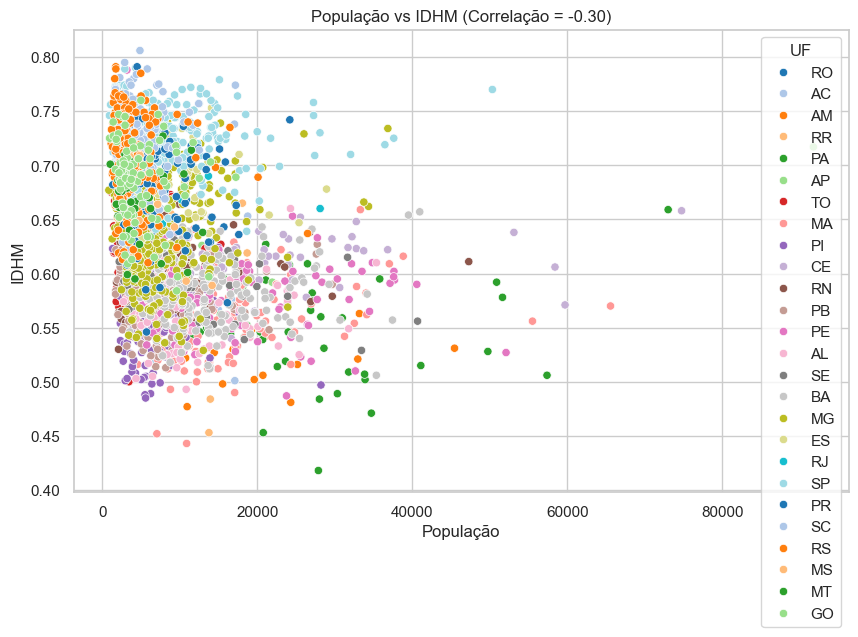

In [28]:
x = df['População']
y = df['IDHM']

correlacao = x.corr(y)
print("Correlação:", correlacao)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='População',
    y='IDHM',
    hue='UF',
    palette='tab20' 
)

plt.title(f'População vs IDHM (Correlação = {correlacao:.2f})')
plt.show()

Para o gráfico de correlação **nacional**, o valor mostrado é aproximadamente **r = -0,30**, indicando uma **correlação negativa fraca a moderada** entre população e IDHM. Isso significa que, no conjunto do país, há uma leve tendência de municípios mais populosos apresentarem IDHM um pouco menor, embora essa relação não seja forte. O scatterplot mostra grande dispersão dos pontos, sugerindo que a população, isoladamente, não explica de forma consistente as variações no IDHM. Também é possível observar a presença de alguns municípios muito populosos que funcionam como pontos extremos (outliers), o que pode influenciar o valor da correlação. De modo geral, o padrão indica que o desenvolvimento humano depende de múltiplos fatores além do tamanho populacional, e que a relação entre essas variáveis não é linear nem determinante em nível nacional.


## 6. Conclusão

Neste estudo dos municípios classificados como desertos de notícia, as estatísticas descritivas mostraram alta heterogeneidade populacional, com presença de municípios muito pequenos e alguns mais populosos.
Os boxplots por UF evidenciaram diferenças importantes entre estados para População, IDHM e IDHM (Educação), com dispersões distintas e presença de outliers.
A análise do primeiro quartil de IDHM permitiu identificar os municípios em condição mais crítica dentro de cada estado, destacando desigualdades intraestaduais relevantes.
No recorte do Nordeste, observou-se padrão semelhante, com variação significativa entre UFs e concentração de municípios em faixas mais baixas de IDHM.
Nas correlações, a relação entre População e IDHM foi fraca no Nordeste e fraca a moderada (negativa) no cenário nacional, indicando que o tamanho populacional, isoladamente, não explica o desenvolvimento humano municipal.
Assim, os resultados sugerem que políticas públicas para desertos de notícia devem considerar múltiplos fatores socioeconômicos e territoriais, e não apenas porte populacional.